<a href="https://colab.research.google.com/github/AlanAmaro13/fruit-classifier10/blob/main/2_HPSearchModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HyperParameters Search

## Used libraries

To perform the HyperParameters search let's gonna use Keras Tuner with Bayesian Optimization.

In [ ]:
! pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.4 MB/s eta 0:00:00


In [ ]:
import keras_tuner

In [ ]:
import seaborn as sns

To improve the workflow we use a _craft-made library_ for the development of Neural Networks.

In [ ]:
import sys
import os

# Add the AmaroXI folder to Python path
sys.path.append('/content/drive/MyDrive/cellularAutomata/fruit_classification/notebooks')

In [ ]:
! pip install python-telegram-bot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.4/745.4 kB 47.7 MB/s eta 0:00:00


In [ ]:
from AmaroXI.AmaroX.ai_functions import *
from AmaroXI.AmaroX.Convolutional import *
from AmaroXI.AmaroX.data_manipulation import *
from AmaroXI.AmaroX.utilities import *
from AmaroXI.AmaroX.DNN import *

## Load data

Let's load the data from the previous pre-processing notebook.

In [ ]:
x_train = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_train.npy')
x_test = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_test.npy')
x_val = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/x_val.npy')

In [ ]:
x_train.shape, x_test.shape, x_val.shape

((2328, 128, 128, 3), (499, 128, 128, 3), (499, 128, 128, 3))

In [ ]:
y_train = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_train.npy')
y_test = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_test.npy')
y_val = np.load('/content/drive/MyDrive/cellularAutomata/fruit_classification/database/y_val.npy')
y_train.shape, y_test.shape, y_val.shape

((2328,), (499,), (499,))

## Seaborn

This section defines the plotting configuration.

In [ ]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
   "figure.dpi": 300,           # Default DPI for new figures
   "savefig.dpi": 300,          # DPI when saving figures

   # Font settings
   "font.family": "sans-serif",     # Universal font family
   "font.size": 11,                   # Base font size

   # Title and label sizes
   "axes.titlesize": 16,             # Axis title size
   "axes.titleweight": "bold",       # Axis title weight
   "axes.labelsize": 14,             # Axis label size
   "axes.labelweight": "semibold",   # Axis label weight

   # -------------------------------------------------

   # Tick LABEL sizes (text next to ticks)
   "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
   "ytick.labelsize": 11,       # Size of y-axis tick labels

   # Tick MARK sizes (physical marks on axes)
   "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
   "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

   # Additional tick parameters you might want to use:
   "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
   "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

   # Tick WIDTH (thickness)
   "xtick.major.width": 1,      # Width/Thickness of major ticks
   "ytick.major.width": 1,      # Width/Thickness of major ticks

   # Tick PADDING (distance from label to tick)
   "xtick.major.pad": 3.5,      # Padding between x-tick and label
   "ytick.major.pad": 3.5,      # Padding between y-tick and label

   # Tick DIRECTIONS
   "xtick.direction": "out",    # "in", "out", or "inout"
   "ytick.direction": "out",    # Points outward from axis

   # Tick COLORS
   "xtick.color": "black",      # Color of x-axis ticks and labels
   "ytick.color": "black",      # Color of y-axis ticks and labels

   # MINOR ticks (for more granular scales)
   "xtick.minor.visible": False,  # Show minor x-ticks
   "ytick.minor.visible": False,  # Show minor y-ticks

   # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
   "xtick.top": False,          # Show ticks on top of plot
   "xtick.bottom": True,        # Show ticks on bottom (default: True)
   "ytick.left": True,          # Show ticks on left (default: True)
   "ytick.right": False,        # Show ticks on right

   # ---------------------------------

   # Legend
   "legend.fontsize": 10,
   "legend.title_fontsize": 12,
   "legend.framealpha":0.9,

   # Figure title (for suptitle)
   "figure.titlesize": 18,
   "figure.titleweight": "bold",

   # ----------------------------------

   # Figure border
   #"figure.edgecolor": "black",
   #"figure.frameon": True,
   #"figure.linewidth": 2.0,

   # Axes borders (spines)
   "axes.linewidth": 1.0,           # Width of axis lines
   "axes.edgecolor": "black",       # Color of axis lines

   # Individual spine control via rcParams
   "axes.spines.top": True,
   "axes.spines.bottom": True,
   "axes.spines.left": True,
   "axes.spines.right": True,

   # ----------------------------
   # Patch properties (for histograms, bars, kde fills, etc.)
   "patch.linewidth": 1.5,           # Default linewidth for patches
   "patch.edgecolor": "black",       # Default edge color
   "patch.facecolor": "blue",        # Default fill color (careful with this!)
   "patch.force_edgecolor": True,    # Always show edges

})

## Visualization

Let's define the following function to visualize our images.

In [ ]:
def show_image(img_array, title=None, figsize=(5, 5)):
    """
    Display a single image from numpy array

    Args:
        img_array: numpy array of shape (height, width, channels) or (height, width)
        title: Optional title for the image
        figsize: Figure size (width, height) in inches
    """
    plt.figure(figsize=figsize)

    # Check if image is normalized (0-1) or not (0-255)
    if img_array.max() <= 1.0 and img_array.min() >= 0:
        # Already normalized
        plt.imshow(img_array)
    else:
        # Assume 0-255 range, clip to valid range
        plt.imshow(np.clip(img_array, 0, 255).astype(np.uint8))

    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

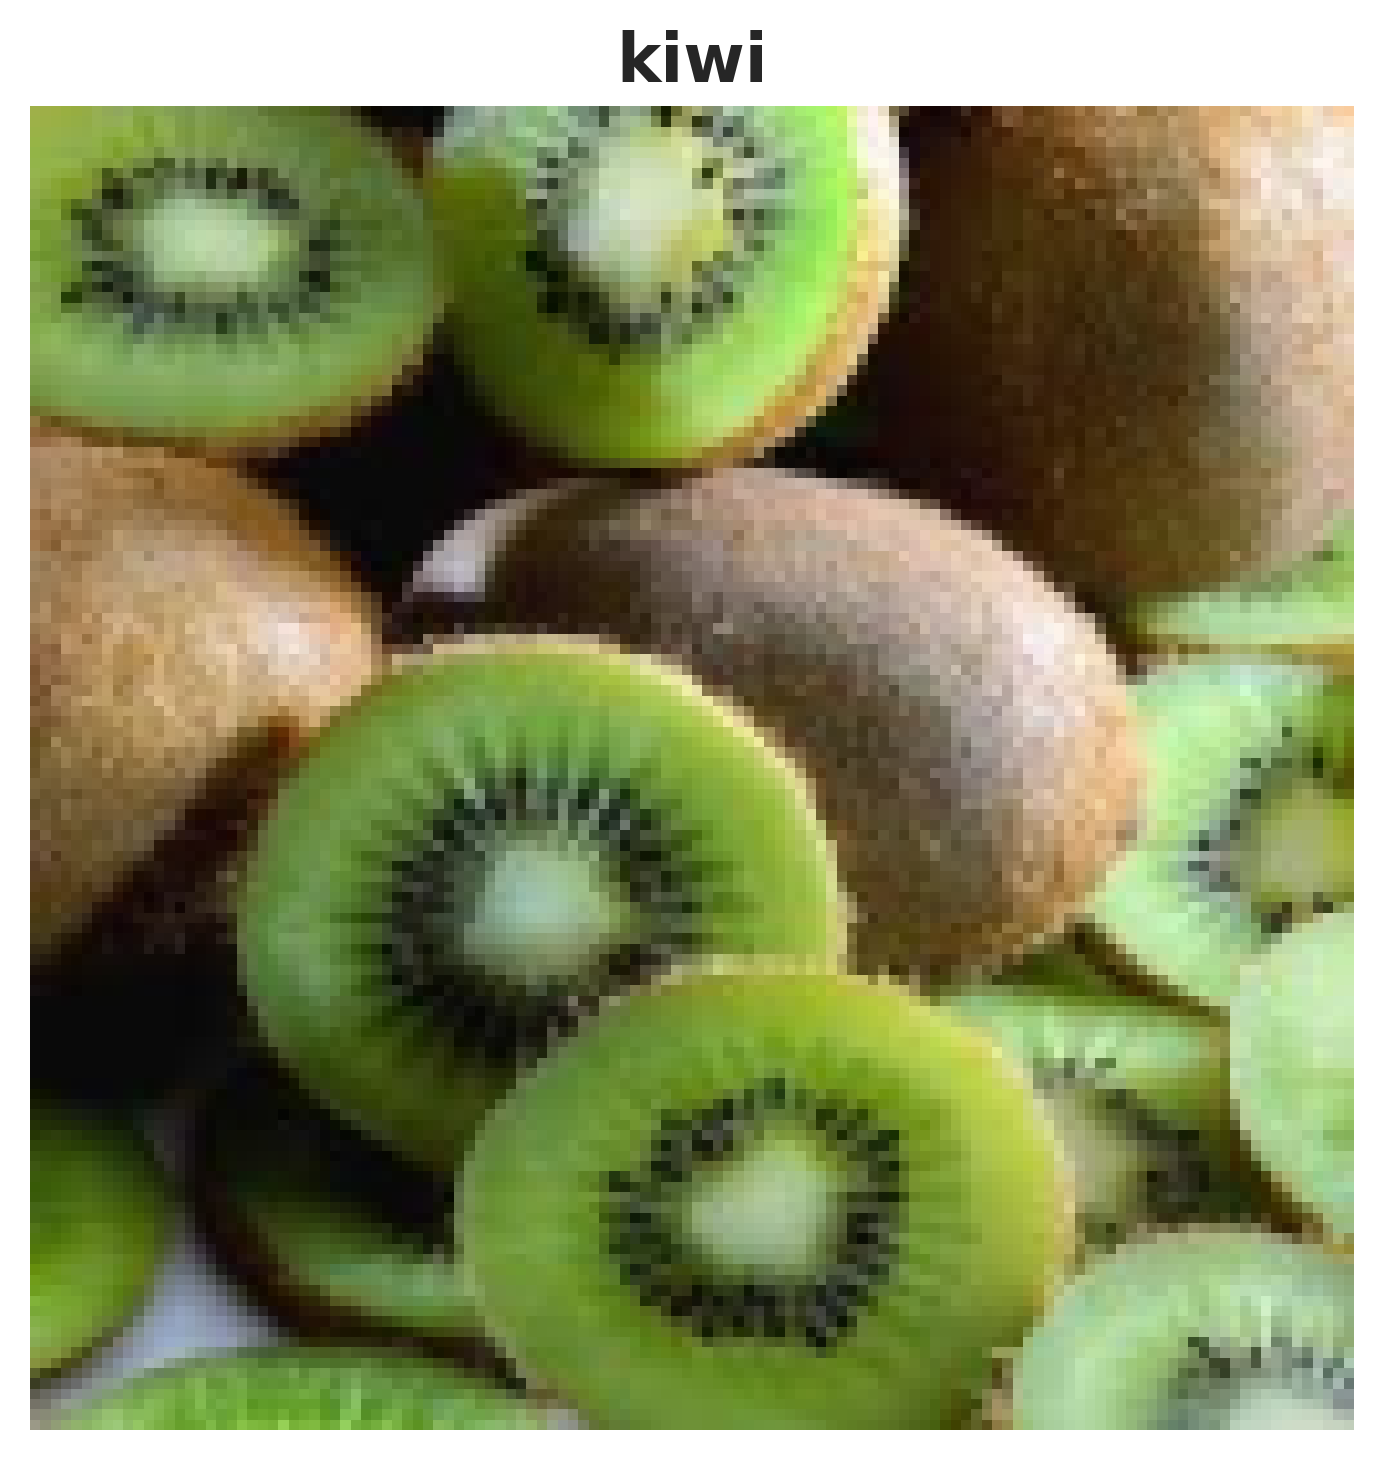

In [ ]:
show_image(x_train[0], title = y_train[0])

## One-Hot Encoding

Our classes are _strings_, we need to convert them into a useful format. First, we convert into integers and later to One-Hot.

The One-Hot representation is a sparse vector of zeros except in one entry with the value of 1.

In [ ]:
set([str(y) for y in y_train])  # List the available classes

{'apple',
 'avocado',
 'banana',
 'cherry',
 'kiwi',
 'mango',
 'orange',
 'pinenapple',
 'strawberries',
 'watermelon'}

Let's define a conversion dictionary to pass from string to integer:

In [ ]:
conversor_dict = {
  'apple':0,
  'avocado':1,
 'banana':2,
 'cherry':3,
 'kiwi':4,
 'mango':5,
 'orange':6,
 'pinenapple':7,
 'strawberries':8,
 'watermelon':9}

Let's do the conversion:

In [ ]:
y_train_int = np.array([ conversor_dict[y] for y in y_train])
y_test_int = np.array([ conversor_dict[y] for y in y_test])
y_val_int = np.array([ conversor_dict[y] for y in y_val])

In [ ]:
y_train_int[0], y_train[0]

(np.int64(4), np.str_('kiwi'))

Now let's convert into the One-Hot representation using built-in functions of Keras.

In [ ]:
def one_hot_keras(labels, num_classes=10):
    """
    Convert labels to one-hot encoding using Keras

    Args:
        labels: Array of shape (n_samples,) with integer labels 0-9
        num_classes: Number of classes (10 for your case)

    Returns:
        One-hot encoded array of shape (n_samples, num_classes)
    """
    return tf.keras.utils.to_categorical(labels, num_classes=num_classes)


y_onehot = one_hot_keras(y_train_int)
print(f"Original shape: {y_train_int.shape}")
print(f"One-hot shape: {y_onehot.shape}")
print(f"Sample: {y_train_int[0]} -> {y_onehot[0]}")

Original shape: (2328,)
One-hot shape: (2328, 10)
Sample: 4 -> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [ ]:
y_train_oh = one_hot_keras(y_train_int)
y_test_oh = one_hot_keras(y_test_int)
y_val_oh = one_hot_keras(y_val_int)

In [ ]:
y_train_oh.shape, y_test_oh.shape, y_val_oh.shape

((2328, 10), (499, 10), (499, 10))

As we might observe, our data has a dimension of (n, 10).

## GPU Allocation

To improve the speed of calculations, let's make use of GPU environments:

In [ ]:
get_gpu(0)

## Paths

In this section we define the used paths to storage the final model:

In [ ]:
folder_path = '/content/drive/MyDrive/cellularAutomata/fruit_classification/notebooks/models'

In [ ]:
name = 'fruitClassifierHPSearch'

In [ ]:
final_path = os.path.join(folder_path, name)
final_path

'/content/drive/MyDrive/cellularAutomata/fruit_classification/notebooks/models/fruitClassifierHPSearch'

In [ ]:
images_path = os.path.join(final_path, 'images')
images_path

'/content/drive/MyDrive/cellularAutomata/fruit_classification/notebooks/models/fruitClassifierHPSearch/images'

## Callbacks

Performance of our models can fluctuate as the training process is still going on. To conserve the model in the _best epoch_ we make use of Callbacks like Checkpoint. Also to conserve a log of all the metrics we make use of CVS Logger.

In [ ]:
def standard_callbacks(folder_name: str, patiences: list, folder_path: str = '../Models',
                       monitor: str = 'val_metric_accuracy', flow_direction = 'max') -> tuple:
    '''
    Description:
        This functions returns the usual callbacks used during training, such as EarlyStopping, ReduceLearningRate, Checkpoint and CSV Logger.
        It also generates the folder in which all the data will be storage.

        By default we consider the next values:
            * EarlyStopping restores the best weights
            * The reduce on the lr is by 0.8 until we reached 1e-6
            * Checkpoint only saves the best model each epoch

    Args:
        folder_name (str): Refers to folder's name
        patiences (list): Refers to the patience values for EarlyStopping and ReduceOnLR
        folder_path (str): Refers to path where the folder will be created
        monitor (str): Variable to be monitored, by default corresponds to 'val_metric_accuracy'
        patiences (list): Refers to the patiences values for EarlyStopping,

    Return: tuple containing
        EarlyStopping (early)
        ReduceLearningRate (reduce_lr)
        CheckPoint (check)
        CSVlogger (csv_logger)
    '''

    i_choice = 0

    _path = folder_path + '/' + folder_name
    os.makedirs(_path, exist_ok = True) # Make the dir

    _main = (
        tf.keras.callbacks.EarlyStopping(
            monitor = monitor[i_choice],
            patience = patiences[0],
            restore_best_weights=True,
            mode = flow_direction[i_choice]),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor[i_choice],
            factor=0.8,
            patience= patiences[1],
            min_lr=1e-6 ),

          [
           tf.keras.callbacks.ModelCheckpoint(
            filepath=  os.path.join(_path, '{}_{}.keras'.format( mont, flow) ),
            save_weights_only=False,
            monitor=mont,
            mode= flow,
            save_freq = 'epoch',
            save_best_only=True)  for mont, flow in zip(monitor, flow_direction)
           ],

            keras.callbacks.CSVLogger( os.path.join(_path, 'training.log') )
           )

    return tuple(item for sublist in _main
                for item in (sublist if isinstance(sublist, list) else [sublist]))

Let's pay attention to the following metrics over the validation set: Loss (Categorical-BCE), Categorical Accuracy, Precision, Recall and AUC.

In [ ]:
callbacks = standard_callbacks(
    folder_name=name,
    folder_path=folder_path,
    patiences=[1000, 1000],  # Adjusted patience values
    monitor=[
        'val_loss',                          # Validation loss (always available)
        #'val_accuracy',                       # Standard accuracy
        #'val_sparse_categorical_accuracy',    # For integer labels
        'categorical_accuracy',
        'val_precision',                       # Precision (macro-averaged)
        'val_recall',                          # Recall (macro-averaged)
        'val_auc'                              # AUC (works with multi-class)
    ],
    flow_direction=[
        'min',  # loss - minimize
        #'max',  # accuracy - maximize
        #'max',  # sparse categorical accuracy - maximize
        'max',  # top-k accuracy - maximize
        'max',  # precision - maximize
        'max',  # recall - maximize
        'max'   # AUC - maximize
    ]
)

In [ ]:
callbacks

(<keras.src.callbacks.early_stopping.EarlyStopping at 0x7cca84bac470>,
 <keras.src.callbacks.csv_logger.CSVLogger at 0x7ccb2f29d7f0>)

## Backbone functions

This couple of functions are inspired by own 1D Version, the only important modifications are the use of 2D convolutionals and the modification of stride and stride shape.

In [ ]:
def G_ConvBlock_2D(inputs: tf.Tensor, filters: int, kernel:list, act_func: str, pad_type:str,
                pool:list, stride:list, WIC:str, WRC, stride_conv: list = (1,1), pool_op = 'AP'):
    '''
    Args:
        inputs (Tensor): The input information for the Conv2D
        filters (int): The number of filters in the Convolutional
        kernel (list): kernel size in the Conv
        stride_conv (list): strides in the Conv
        WIC (str): Kernel Initializer in the Conv
        WRC (str): Kernel Regulatier in the Conv
        act_func (str): Activation Function
        pool (list): pool size in the pooling layer
        stride (list): stride size in the pooling layer

    Flux:
        Conv->BN->Activation->AP

    Observations:
        1. The Convolutionals preserves dimension. When padding="same" and strides=(1,1), the output has the same size as the input
        2. Before is the BatchNormalization and after the Activation.
        3. The dimension after the Conv is
            (input_shape - pool_size + 1) / strides)

    Test:



    Pooling Operations:
    Downsamples the input representation by taking the maximum value over a spatial window of size pool_size.
    The window is shifted by strides.

    The resulting output when using the "valid" padding option has a shape of: output_shape = (input_shape - pool_size + 1) / strides).

    The resulting output shape when using the "same" padding option is: output_shape = input_shape / strides
    '''

    Conv = keras.layers.Conv2D(
        filters = filters,
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(inputs)

    BN = keras.layers.BatchNormalization()(Conv)
    Act = keras.layers.Activation(activation = act_func)(BN)

    if pool_op == 'AP':
        AP = keras.layers.AveragePooling2D(
            pool_size = pool,
            strides = stride,
            padding = pad_type
            )(Act)
    elif pool_op == 'MP':
        AP = keras.layers.MaxPooling2D(
        pool_size = pool,
        strides = stride,
        padding = pad_type
        )(Act)

    elif pool_op == None:
        AP = Act

    return AP

# ---------- Convolutional Neural Network

def CNN_2D(inputs: tf.Tensor, filters:list, kernel:list, pad_type:str, pool:list, stride:list, nodes: list, DP: int, n_final: int,
       WIC:str, WRC, stride_conv:list = (1,1), pool_op:str= 'AP', act_func: str = 'leaky_relu',
        final_act_func: str = 'softmax', WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0, use_bias: bool = False,
       act_func_conv:str = 'leaky_relu'):
    '''
    Desc:
        This function is used to create a Convolutional Neural Network. It provides a easy interface to perform Hyper-parameters research.

        The initial component is the input, this is usually a keras.layers.Input((n,1)), where n is the dimension of the signal. To define
        the number of ConvBlock we used a list for the filters, each element in this list represents the filter for each ConvBlock. We also
        provide the use the ability to change the kernel size depending of the ConvBlock (if you want to set a fix kernel size just use
        the operation Deep*[kernel_size]).

        The activation function for the convolutional is set to LeakyReLU (better results might be obtained with a SReLU). An important note
        is:

        * The Convolutional section preverves the dimensionality. This means that all the reduction is performed by the Pooling Operations.
        This also implies that the padding in the Conv is set to 'same' and stride_conv=(1,1).

        The Pooling Operations are configured to be:
        * AP: Average Pooling
        * MP: Max Pooling
        It's easy to observe that a new pooling operation can be added without major problem. The parameters to reduce dimension are: pad_type,
        pool and stride, the final dimension is calculated as follows:

        - The resulting output when using the "valid" padding option has a shape of: output_shape = (input_shape - pool_size + 1) / strides).

        - The resulting output shape when using the "same" padding option is: output_shape = input_shape / strides

        WIC means Weight Initializer for the Convolutional. The best WIC is He Normal (or He Uniform, depending if the architecture has BachNorm),
        WRC means Weight Regularizer, I recommend the use of L1L2.

        This flux is repeated for each filter in filters. After the convolutional operations, a flatten operation is applied. Then we employ
        the G_Dense section. Here the input is the output flatten, the nodes are defined as a list, where each elements are the nodes in each
        hidden layer. WI means Weight initializer (again, I recommend use He Normal). For regularization I added Dropout (integer number
        represeting a porcentage), L1L2 (ElasticNet). The activation function inside the architecture might be different from the final, so I
        give that option (I use LeakyReLU for hiddden layers and ReLU for output). Finally, you can decide whether you want to use bias in the
        Dense Layers.

    Args:
        inputs (tf.Tensor): This is the Tensor input.
        filters (list): This list contains each filter for each convolutional block.
        kernel (list): This list contains the kernel size for each convolutional block.
        act_func (str): This is the activation function, I really recommed use a rectified operation, such as LeakyReLU, ReLU, PReLU, SRELU.

        -> These parameters are for the Pooling Operation.
        pad_type (str):
        pool (list):
        stride (list):

        WIC (str): This is the Weight Initializer for the Convolutional, I really recommend using He Normal (because the BatchNorm).
        WRC (KerasObject): This is the kernel regularizer, I really recommend using L1L2, varying the values.
        stride_conv (list): This is the stride for the Convolutional

        pool_op (str): This is the Pooling Operation.

    Returns:
        CNN Model

    Flux:
        ConvBlock -> ConvBlock -> ... -> Flatten -> G_Dense

    Example:
        modelo = CNN_2D(
            inputs = keras.layers.Input((128, 128 ,1)),
            filters = [256, 128, 64],
            kernel = [(11, 11), (5,5), (3,3)],
            pad_type = 'valid',
            pool = (4,4),
            stride = (4,4),
            nodes = [50, 25, 5],
            DP = 5,
            n_final = 1,
            WIC = 'he_normal',
            WRC = keras.regularizers.L1L2(l1 = 1e-6, l2 = 1e-6),
            final_act_func= 'relu',
            L1 = 1e-6,
            L2 = 1e-6,
            use_bias = True
        )
    '''

    _stage = G_ConvBlock_2D(
        inputs = inputs,
        filters = filters[0],
        kernel = kernel[0],
        act_func = act_func_conv,
        pad_type = pad_type,
        pool = pool,
        stride = stride,
        WIC = WIC,
        WRC = WRC,
        stride_conv=stride_conv,
        pool_op=pool_op
    )

    for i in range(len(filters[0:])):
        _stage = G_ConvBlock_2D(
            inputs = _stage,
            filters = filters[i],
            kernel = kernel[i],
            act_func = act_func_conv,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv=stride_conv,
            pool_op=pool_op
        )

    _flatten = keras.layers.Flatten()(_stage)

    _dense = G_Dense(
        inputs = _flatten,
        nodes = nodes,
        DP = DP,
        n_final = n_final,
        act_func = act_func,
        final_act_func= final_act_func,
        WI = WI,
        L1 = L1,
        L2 = L2,
        use_bias = use_bias
    )

    return keras.models.Model(inputs = inputs, outputs = _dense)

## Seed

To secure _certain level_ of reproducibility, let's set the seed of the weights in the model.

In [ ]:
seed = np.random.randint(2**32 - 1)
seed

2013566315

In [ ]:
keras.utils.set_random_seed(seed)

## Model

The HyperParameters space to look up consists in the number of filters, nodes, Dropout, L1L2 in the Convolutionals and L1L2 in the Neural Network section.

To limit the space search let's consider the CNN composed of three layers with the double of filters based on the previous one.

For the NN section, let's consider that the number of nodes decrease in a half for each layer.



* We've added a RandAugmentation to increase the precision of the search.

In [ ]:
def CNN_Model(filters: list, nodes: list, DP:int, l1c:float, l2c:float, l1:float, l2:float ):
  inputs = keras.layers.RandAugment(
        value_range=(0, 1),
        num_ops=2,
        factor=0.5,
    )(
        keras.layers.Input( (128, 128, 3) )
    )

  __CNN_2D = CNN_2D(
      inputs = inputs,
      filters = filters,
      kernel = [(8,8), (4,4), (2,2)],
      pad_type = 'valid',
      pool = (2,2),
      stride = (2,2),
      nodes = nodes,
      DP = DP,
      n_final = 10,
      WIC = 'he_normal',
      WRC = keras.regularizers.L1L2(l1 = l1c, l2 = l2c),
      final_act_func= 'softmax',
      L1 = l1,
      L2 = l2,
      use_bias = True
  )


  return __CNN_2D

We consider the same metrics and optimizer as in the Test Model.

In [ ]:
def compile_model(filters: list, nodes: list, DP:int, l1c:float, l2c:float, l1:float, l2:float, modelo):

  model = modelo(filters = filters, nodes = nodes, DP=DP, l1c=l1c, l2c=l2c, l1=l1, l2=l2)

  model.compile(optimizer = keras.optimizers.Adam(learning_rate=0.001),
                loss = 'categorical_crossentropy',
                metrics = [
                keras.metrics.AUC(),
                keras.metrics.Precision(),
                keras.metrics.Recall(),
                keras.metrics.CategoricalAccuracy(),
                #keras.metrics.SparseCategoricalAccuracy(),
                #keras.metrics.Accuracy()
                #keras.metrics.F1Score()
                ]
                )

  return model

Our space search goes from 1 to 50 filters at a step of 5. For nodes it goes from 10 to 500 at a resolution of 5. Dropout is set from 0% to 50% at a resolution of 5%.

For the Convolutional and Nodes layers the L1L2 regularizer is applied at discrete steps from [1e-6 up to 1].



In [ ]:
def build_model(hp):

  f1 = hp.Int('Filters', min_value = 1, max_value = 50, step = 5)

  n1 = hp.Int('Nodes', min_value = 10, max_value = 500, step = 5)

  filters = [f1, 2*f1, 4*f1] # Let's fix the double in each convolutional layer.

  nodes = [ n1, n1//2, n1//4 ] # The number of nodes in each layer is reduced.

  DP = hp.Int('Dropout', min_value = 0, max_value = 50, step = 5)

  l1 = hp.Choice('L1', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  l2 = hp.Choice('L2', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  l1c = hp.Choice('L1C', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

  l2c = hp.Choice('L2C', [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])


  model_f = compile_model(
      filters = filters,
      nodes = nodes,
      l1 = l1,
      l2 = l2,
      l1c = l1c,
      l2c = l2c,
      DP = DP,
      modelo = CNN_Model)

  return model_f

## Bayesian Optimization

In [ ]:
build_model(keras_tuner.HyperParameters())

<Functional name=functional, built=True>

Let's use BayesianOptimization with 50 trials, for each trial we consider 2 iterations. Our objetive is the metric categorical accuracy over the validation set with its higher value.



In [ ]:
tuner = keras_tuner.BayesianOptimization(
    hypermodel=build_model,
    objective= keras_tuner.Objective('val_categorical_accuracy', 'max') ,
    max_trials= 50, # Set to 3
    executions_per_trial = 2,
    overwrite=True,
    directory= final_path,
    project_name="CNN_HP_Bayesian_25_2_CategoricalCorssEntropy_Max",
)

In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 7
Filters (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 50, 'step': 5, 'sampling': 'linear'}
Nodes (Int)
{'default': None, 'conditions': [], 'min_value': 10, 'max_value': 500, 'step': 5, 'sampling': 'linear'}
Dropout (Int)
{'default': None, 'conditions': [], 'min_value': 0, 'max_value': 50, 'step': 5, 'sampling': 'linear'}
L1 (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L2 (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L1C (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}
L2C (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0], 'ordered': True}


Let's consider 50 epochs for each training, with the same batch size as the previous model.

In [ ]:
tuner.search(x_train, y_train_oh, epochs=50, validation_data=(x_test, y_test_oh), batch_size=64)

Trial 50 Complete [00h 03m 47s]
val_categorical_accuracy: 0.6212424635887146

Best val_categorical_accuracy So Far: 0.6282565295696259
Total elapsed time: 02h 26m 24s


In [ ]:
file_path = os.path.join(final_path, 'best_models.txt')

with open(file_path, "w") as file:
    # Save the original stdout
    original_stdout = sys.stdout
    try:
        sys.stdout = file  # Redirect stdout to the file
        tuner.results_summary()  # Call your function
    finally:
        sys.stdout = original_stdout